# Which delivered orders may miss the promised date?

**The question.** Can information plausibly available at checkout help an operations team spot later deliveries?

The notebook tells the story using saved training and validation results. It does not fit a model or inspect the reserved later-period test. Read the [short glossary](#A-short-glossary) before the charts if the metrics are unfamiliar.

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve

ROOT = Path.cwd()
if not (ROOT / "results/phase2/classification/selection.json").exists():
    ROOT = Path.cwd().parents[1]
OUT = ROOT / "results/phase2/classification"
DATA = ROOT / "data"
selection = json.loads((OUT / "selection.json").read_text())
spec = json.loads((DATA / "phase2_feature_spec.json").read_text())
assert selection["primary_test_evaluated"] is False
assert selection["final_model_fitted"] is False
for filename, expected in selection["input_sha256"].items():
    assert hashlib.sha256((DATA / filename).read_bytes()).hexdigest() == expected, filename
for filename, key in [("phase2_classification.py", "implementation_sha256"),
                      ("phase2_features.py", "features_module_sha256")]:
    assert hashlib.sha256((ROOT / filename).read_bytes()).hexdigest() == selection[key], filename

def read(name):
    return pd.read_csv(OUT / f"{name}.csv")

ladder = read("ladder_summary")
cv = read("cv_metrics")
summary = read("cv_summary")
folds = read("folds")
months = read("monthly_late_rate")
splits = read("split_comparison")
payments = read("payment_sensitivity")
signal = read("feature_signal")
correlation = read("feature_correlation").set_index("Unnamed: 0")
odds = read("logistic_odds_ratios")
importance = read("forest_permutation_importance")
ranking = read("risk_ranking")
thresholds = read("threshold_metrics")
predictions = read("selected_validation_predictions")
assert len(predictions) == selection["validation_orders"]
assert predictions["fold"].nunique() == spec["n_folds"]
assert predictions["order_id"].is_unique
assert set(predictions["is_late"].unique()) == {0, 1}

BASE = "#88919b"; LINEAR = "#266f9b"; FOREST = "#d28439"; LATE = "#b44548"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold"})
def row(candidate):
    return summary.set_index("candidate").loc[candidate]
def pct(x):
    return f"{x:.1%}"

In [2]:
base = row("prior_baseline")["mean_average_precision"]
chosen = row(selection["selected_candidate"])["mean_average_precision"]
forest_ap = row(selection["family_winners"]["tree_based"])["mean_average_precision"]
top10 = ranking.query('scope == "all_folds" and top_share == 0.1').iloc[0]
train_rate = months["late_orders"].sum() / months["orders"].sum()
display(Markdown(f"""**At a glance**

- We predict whether a *delivered* order arrives after its promised calendar date, using information assumed available just after checkout.
- Mean PR-AUC across the validation windows rises from **{base:.3f}** for a prior-only baseline to **{chosen:.3f}** for the selected logistic regression.
- The best forest scores **{forest_ap:.3f}** on the same windows. That tiny gap does not establish a meaningful winner.
- Historical periods differ sharply, and important causes of delay may arise after checkout. These are modest validation results, not a final test score.
- If staff review the riskiest **{top10['top_share']:.0%}** *within each window*, they find **{top10['recall']:.1%}** of its late orders: **{top10['lift']:.1f} times** what a random selection would find.

**What we learned.** There is a useful risk-ranking signal, but no independently validated yes/no decision rule or final-period result yet."""))

**At a glance**

- We predict whether a *delivered* order arrives after its promised calendar date, using information assumed available just after checkout.
- Mean PR-AUC across the validation windows rises from **0.107** for a prior-only baseline to **0.200** for the selected logistic regression.
- The best forest scores **0.200** on the same windows. That tiny gap does not establish a meaningful winner.
- Historical periods differ sharply, and important causes of delay may arise after checkout. These are modest validation results, not a final test score.
- If staff review the riskiest **10%** *within each window*, they find **23.5%** of its late orders: **2.3 times** what a random selection would find.

**What we learned.** There is a useful risk-ranking signal, but no independently validated yes/no decision rule or final-period result yet.

## A short glossary

**The question.** What do the scores in this notebook actually measure?

| Term | Plain-English meaning |
|---|---|
| Baseline | A simple reference that gives every order the same risk: the late rate in the orders used to fit it. It cannot rank orders. |
| Precision | Among orders flagged as late, the share that really were late. |
| Recall | Among all late orders, the share caught by the flag or risk shortlist. |
| PR-AUC (average precision) | How well a risk ranking concentrates late orders near the top. Its no-skill reference is the late-order rate. We use scikit-learn's average precision, not geometric area under a drawn curve. |
| ROC-AUC | How often a randomly chosen late order ranks above a randomly chosen on-time order. Random ranking scores one-half. |
| MCC | A summary of correct and incorrect yes/no alerts that accounts for both classes. Zero is chance-like and one is perfect. |
| Lift | How many times more late orders a shortlist catches than a random shortlist of the same size. |

**What we learned.** Ranking scores and alert scores answer different questions; the class rate matters when interpreting PR-AUC and precision.

## 1. The problem

**The question.** What can the team know when an order has just been placed?

An operations team could prioritise orders that may need attention before a promise is missed. Here “late” means the actual **calendar date** of delivery is after the estimated delivery date. Delivery on the promised date counts as on time. We study orders that eventually have a recorded delivery; cancellation and non-delivery are separate outcomes.

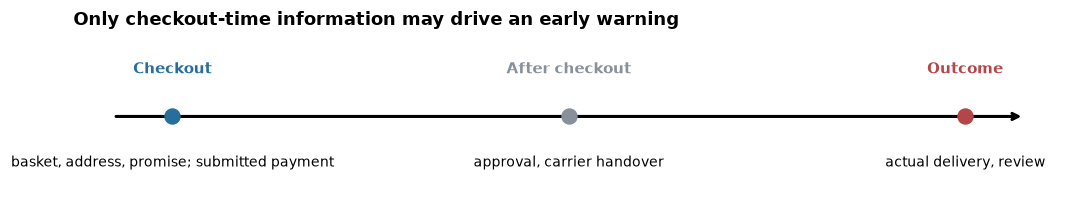

**What we learned.** Delivery, carrier and review fields can define or explain outcomes later; they cannot be inputs to a checkout-time prediction. Historical seller and route summaries use only events completed before each purchase.

In [3]:
fig, ax = plt.subplots(figsize=(10, 2.1))
ax.set_xlim(0, 10); ax.set_ylim(-0.7, 1); ax.axis("off")
ax.annotate("", xy=(9.6, 0.2), xytext=(0.4, 0.2), arrowprops={"arrowstyle": "->", "lw": 2})
for x, title, note, colour in [(1, "Checkout", "basket, address, promise; submitted payment", LINEAR),
                               (5, "After checkout", "approval, carrier handover", BASE),
                               (9, "Outcome", "actual delivery, review", LATE)]:
    ax.scatter([x], [.2], s=95, color=colour, zorder=3)
    ax.text(x, .62, title, ha="center", weight="bold", color=colour)
    ax.text(x, -.18, note, ha="center", va="top", fontsize=9)
ax.set_title("Only checkout-time information may drive an early warning", loc="left")
plt.tight_layout(); plt.show()
display(Markdown("**What we learned.** Delivery, carrier and review fields can define or explain outcomes later; they cannot be inputs to a checkout-time prediction. Historical seller and route summaries use only events completed before each purchase."))

## 2. The data we are working with

**The question.** How common is lateness, and does its frequency stay steady?

The [data-preparation notebook](data_prep.ipynb) starts with the raw Olist tables, makes one row per delivered order, and builds checkout-time candidates. This chart uses only the primary training period. The few earliest months with very small counts are omitted from the chart, but remain in the overall rate.

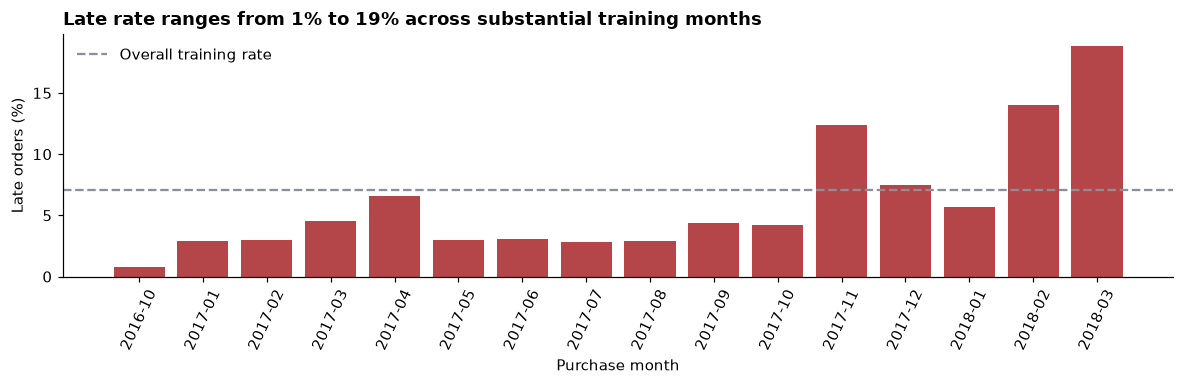

**What we learned.** Of the 75,099 training orders, 7.1% are late. Through 2018-03, across months with at least 265 orders, the rate moves from 0.8% to 18.9%. A fixed alert cutoff may therefore behave differently at different times. More recent training months are omitted from this chart because deliveries still in transit at the cutoff could make their observed late rate misleading.

In [4]:
last_validation_month = pd.to_datetime(folds["validation_end"].max()).strftime("%Y-%m")
shown = months.loc[(months["orders"] >= 100) & (months["purchase_month"] <= last_validation_month)].copy()
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(shown["purchase_month"], shown["late_rate"] * 100, color=LATE)
ax.axhline(train_rate * 100, color=BASE, ls="--", label="Overall training rate")
ax.set_ylabel("Late orders (%)"); ax.set_xlabel("Purchase month")
ax.tick_params(axis="x", rotation=65); ax.legend(frameon=False)
ax.set_title(f"Late rate ranges from {shown['late_rate'].min():.0%} to {shown['late_rate'].max():.0%} across substantial training months", loc="left")
plt.tight_layout(); plt.show()
display(Markdown(f"**What we learned.** Of the {months['orders'].sum():,} training orders, {train_rate:.1%} are late. Through {last_validation_month}, across months with at least {shown['orders'].min():,} orders, the rate moves from {shown['late_rate'].min():.1%} to {shown['late_rate'].max():.1%}. A fixed alert cutoff may therefore behave differently at different times. More recent training months are omitted from this chart because deliveries still in transit at the cutoff could make their observed late rate misleading."))

## 3. Why testing is harder than it looks

**The question.** Does a model that recognises patterns in the historical mix also work on *later* purchases?

Our main check repeatedly fits on earlier purchases with known outcomes and scores the next window. An order still in transit when a fit begins cannot supply a label. The validation windows also end well before the later-period test, allowing time for outcomes to settle. The random comparison below reshuffles **only eligible rows from the primary training period**; it never uses the reserved later-period test.

In [5]:
comparison = splits.pivot(index="candidate", columns="split", values=["mean_average_precision", "mean_roc_auc"])
comparison.columns = [f"{metric}_{split}" for metric, split in comparison.columns]
comparison = comparison.reset_index()
comparison["model"] = comparison["candidate"].map({"logistic_c01":"Logistic regression", "forest_depth12":"Random forest"})
display(comparison[["model", "mean_average_precision_time_based", "mean_average_precision_random", "mean_roc_auc_time_based", "mean_roc_auc_random"]].rename(columns={
    "model":"Model", "mean_average_precision_time_based":"PR-AUC: time", "mean_average_precision_random":"PR-AUC: random",
    "mean_roc_auc_time_based":"ROC-AUC: time", "mean_roc_auc_random":"ROC-AUC: random"}).style.format(precision=3).hide(axis="index"))
fold_view = folds[["fold", "validation_start", "validation_end", "late_rate"]].copy()
fold_view["window"] = fold_view["fold"].add(1)
fold_view["from"] = fold_view["validation_start"].str[:10]
fold_view["to"] = fold_view["validation_end"].str[:10]
fold_lines = [f"- Window {int(r.window)}: {r['from']} to {r['to']}; {r.late_rate:.1%} late"
              for _, r in fold_view.iterrows()]
display(Markdown("**The future-facing validation windows:**\n" + "\n".join(fold_lines)))
linear_cmp = comparison.loc[comparison.candidate.eq("logistic_c01")].iloc[0]
display(Markdown(f"**What we learned.** The same logistic settings score {linear_cmp['mean_average_precision_random']:.3f} mean PR-AUC in shuffled folds but {linear_cmp['mean_average_precision_time_based']:.3f} in the future-facing folds. Mixing dates gives an easier question, so we select models with the time-based windows. Both numbers are means of window scores; they are not pooled scores."))

Model,PR-AUC: time,PR-AUC: random,ROC-AUC: time,ROC-AUC: random
Random forest,0.200,0.327,0.668,0.767
Logistic regression,0.200,0.303,0.677,0.758


**The future-facing validation windows:**
- Window 1: 2017-09-22 to 2017-11-14; 4.1% late
- Window 2: 2017-11-14 to 2017-12-11; 13.8% late
- Window 3: 2017-12-11 to 2018-01-20; 4.8% late
- Window 4: 2018-01-20 to 2018-02-22; 9.9% late
- Window 5: 2018-02-22 to 2018-03-26; 20.7% late

**What we learned.** The same logistic settings score 0.303 mean PR-AUC in shuffled folds but 0.200 in the future-facing folds. Mixing dates gives an easier question, so we select models with the time-based windows. Both numbers are means of window scores; they are not pooled scores.

## 4. What signal is in the features?

**The question.** Are the inputs distinct, and can any one of them reliably separate late from on-time orders?

The three added historical features are a route's previously observed delivery time, how much longer the promise is than that route history, and a seller's previous speed of handing parcels to carriers. They only use earlier completed events. The correlation chart summarises rank relationships among numeric inputs in the training period; it does not show causes.

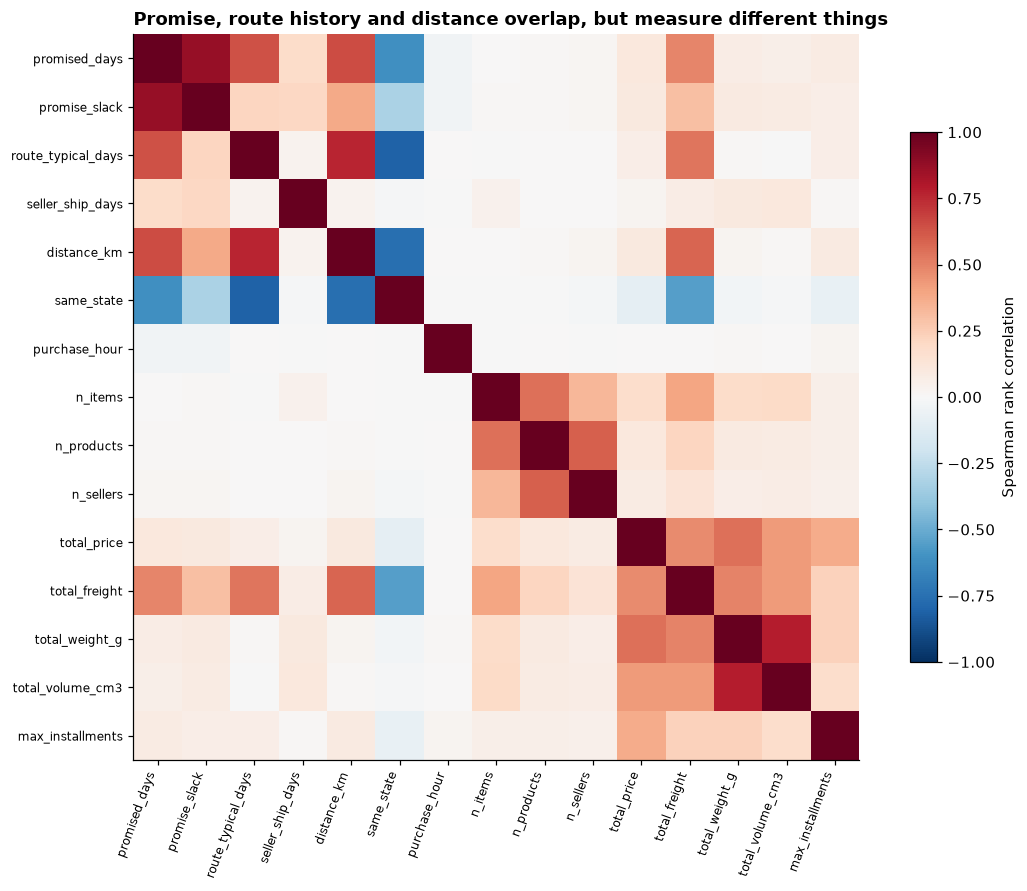

**Pairs kept deliberately:** `promised_days` with `promise_slack` (+0.87); `route_typical_days` with `same_state` (-0.81); `total_weight_g` with `total_volume_cm3` (+0.78); `route_typical_days` with `distance_km` (+0.76); `distance_km` with `same_state` (-0.75). Related inputs can share predictive credit; correlation alone is not a reason to delete them.

In [6]:
corr = correlation.astype(float)
fig, ax = plt.subplots(figsize=(10.5, 8.2))
mat = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=70, ha="right", fontsize=8)
ax.set_yticks(range(len(corr.index)), corr.index, fontsize=8)
fig.colorbar(mat, ax=ax, shrink=.73, label="Spearman rank correlation")
ax.set_title("Promise, route history and distance overlap, but measure different things", loc="left")
plt.tight_layout(); plt.show()
strong = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong = strong[strong.abs() >= .4].sort_values(key=lambda s:s.abs(), ascending=False)
display(Markdown("**Pairs kept deliberately:** " + "; ".join(f"`{a}` with `{b}` ({v:+.2f})" for (a,b),v in strong.head(5).items()) + ". Related inputs can share predictive credit; correlation alone is not a reason to delete them."))

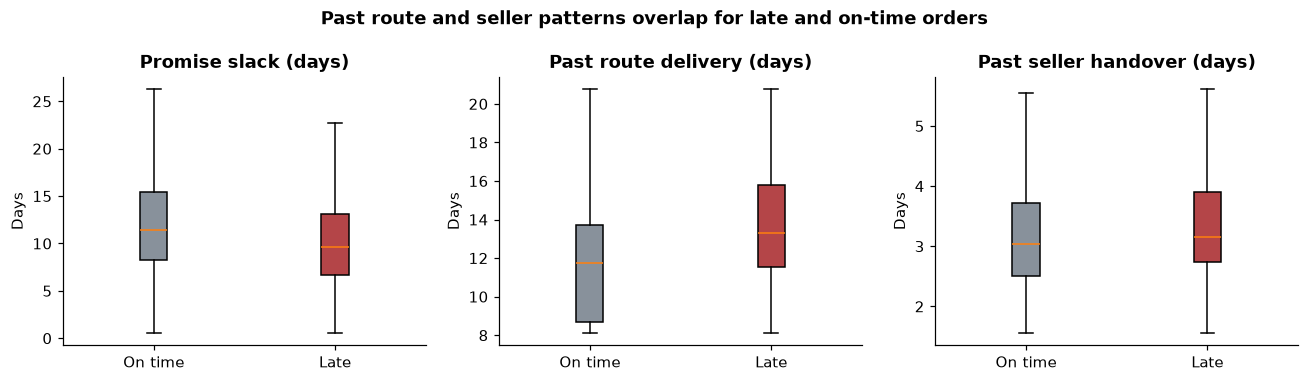

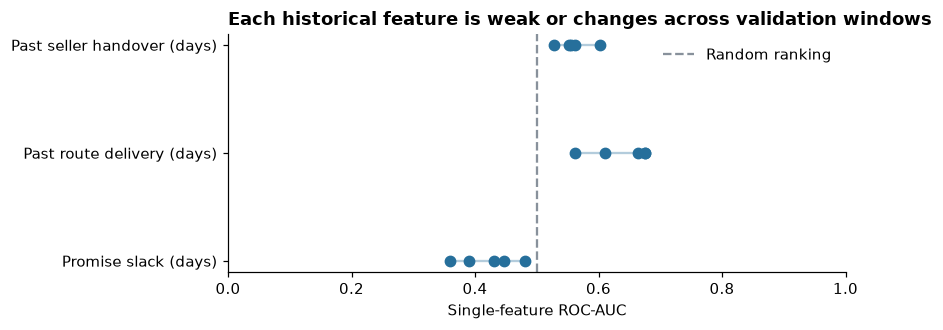

**What we learned.** These distributions overlap heavily. Promise slack has mean single-feature ROC-AUC **0.422**, below the 0.5 random-ranking reference because a *looser* promise tends to mean **less** lateness. That direction is sensible, not a reversed label. The boxplots clip displayed values to the training-period percentile range; the underlying modelling data are unchanged.

In [7]:
wanted = ["promise_slack", "route_typical_days", "seller_ship_days"]
needed = ["split", "is_late", *wanted]
parts = []
for chunk in pd.read_csv(DATA / "phase2_order_table.csv", usecols=needed, chunksize=30000):
    parts.append(chunk.loc[chunk["split"].eq("train"), ["is_late", *wanted]])
training_view = pd.concat(parts, ignore_index=True)
assert len(training_view) == selection["train_orders"]
labels = {"promise_slack":"Promise slack (days)", "route_typical_days":"Past route delivery (days)",
          "seller_ship_days":"Past seller handover (days)"}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, feature in zip(axes, wanted):
    values = training_view[feature].dropna()
    low, high = values.quantile([.01, .99])
    samples = [training_view.loc[training_view.is_late.eq(cls), feature].clip(low, high).dropna()
               for cls in [0,1]]
    box = ax.boxplot(samples, patch_artist=True, showfliers=False, tick_labels=["On time", "Late"])
    for patch, color in zip(box["boxes"], [BASE, LATE]): patch.set_facecolor(color)
    ax.set_title(labels[feature]); ax.set_ylabel("Days")
fig.suptitle("Past route and seller patterns overlap for late and on-time orders", weight="bold")
plt.tight_layout(); plt.show()
signal_view = signal[signal.feature.isin(wanted)]
fig, ax = plt.subplots(figsize=(8, 3.1))
for i, feature in enumerate(wanted):
    vals = signal_view.loc[signal_view.feature.eq(feature)].sort_values("fold")
    ax.scatter(vals.roc_auc, [i]*len(vals), color=LINEAR, s=45)
    ax.plot([vals.roc_auc.min(), vals.roc_auc.max()], [i,i], color=LINEAR, alpha=.35)
ax.axvline(.5, color=BASE, ls="--", label="Random ranking")
ax.set_yticks(range(len(wanted)), [labels[f] for f in wanted]); ax.set_xlabel("Single-feature ROC-AUC")
ax.set_xlim(0,1); ax.legend(frameon=False)
ax.set_title("Each historical feature is weak or changes across validation windows", loc="left")
plt.tight_layout(); plt.show()
slack_mean = signal_view.loc[signal_view.feature.eq("promise_slack"), "roc_auc"].mean()
display(Markdown(f"**What we learned.** These distributions overlap heavily. Promise slack has mean single-feature ROC-AUC **{slack_mean:.3f}**, below the {row('prior_baseline')['mean_roc_auc']:.1f} random-ranking reference because a *looser* promise tends to mean **less** lateness. That direction is sensible, not a reversed label. The boxplots clip displayed values to the training-period percentile range; the underlying modelling data are unchanged."))

## 5. Did each extra step help?

**The question.** Which added modelling choices and historical features actually improved future-facing validation?

A constant baseline comes first. We then compare simple and constrained models, test class weighting, and change one feature group at a time while model settings stay fixed. Month was dropped after validation showed it hurt transfer to later windows; the historical record offers little repeated evidence for the same season. Route and seller summaries are built only from events completed before each purchase. PR-AUC values below are **means of the validation-window scores**; a small difference should not be treated as a firm win.

Step / line,What changed,PR-AUC,Change vs named prior,ROC-AUC,PR-AUC ÷ late rate,Windows better
1 · baseline,Baseline: always predict the training late rate,0.107,—,0.500,1.00×,—
2 · linear,Logistic: default settings,0.170,+0.063,0.615,1.58×,5/5
3 · linear,Logistic: stronger regularisation (C=0.1),0.181,+0.011,0.638,1.68×,5/5
4 · linear,Logistic: class-weighted (vs default),0.160,-0.010,0.600,1.49×,0/5
5 · tree,"Decision tree, default settings",0.109,+0.002,0.508,1.02×,5/5
6 · tree,"Decision tree, constrained (depth 12, leaf 20)",0.139,+0.030,0.555,1.29×,5/5
7 · tree,"Random forest, default settings",0.142,+0.033,0.591,1.33×,5/5
8 · tree,"Random forest, constrained (depth 12, leaf 20)",0.169,+0.027,0.632,1.58×,5/5
9 · linear,Drop purchase_month,0.190,+0.009,0.656,1.74×,3/5
9 · tree,Drop purchase_month,0.186,+0.017,0.647,1.70×,5/5


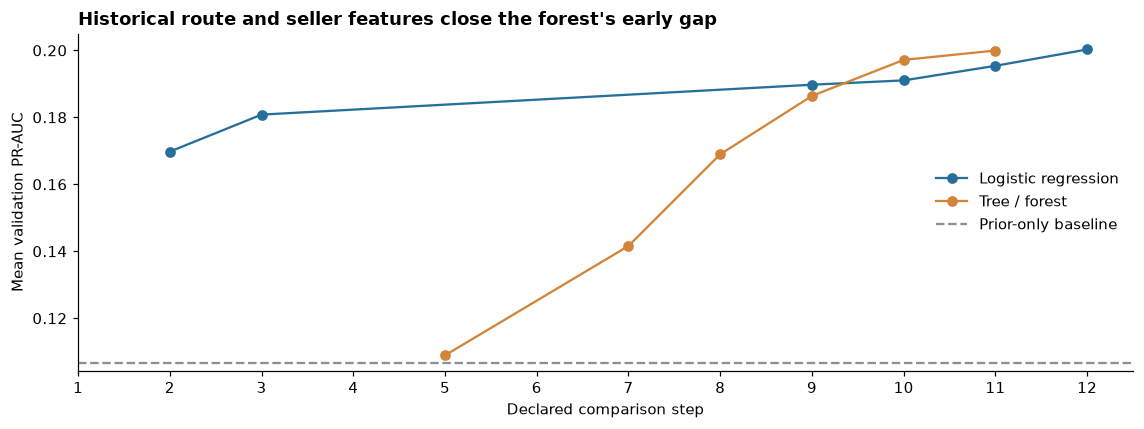

**Reading the ladder:** the chart follows the chosen paths; the class-weighted model and constrained single tree are side comparisons in the table. Each change is compared with the candidate named in the saved `compared_with` column, not always the preceding row. The multiple of the late rate is the mean of the within-window multiples, not a pooled statistic. Differences of only a few thousandths of PR-AUC are too small here to call practical improvements.

In [8]:
ladder_view = ladder.copy()
ladder_view["step_name"] = ladder_view["step"].astype(str) + " · " + ladder_view["line"].replace({"tree_based":"tree", "linear":"linear"})
ladder_view["change"] = ladder_view["label"].str.replace("Logistic regression, ", "Logistic: ", regex=False)
ladder_view["delta"] = ladder_view["delta_average_precision"].map(lambda x: "—" if pd.isna(x) else f"{x:+.3f}")
ladder_view["windows"] = ladder_view["folds_improved_ap"].map(lambda x: "—" if pd.isna(x) else f"{int(x)}/{len(folds)}")
display(ladder_view[["step_name","change","mean_average_precision","delta","mean_roc_auc","mean_ap_over_late_rate","windows"]].rename(columns={
    "step_name":"Step / line", "change":"What changed", "mean_average_precision":"PR-AUC", "delta":"Change vs named prior",
    "mean_roc_auc":"ROC-AUC", "mean_ap_over_late_rate":"PR-AUC ÷ late rate", "windows":"Windows better"})
    .style.format({"PR-AUC":"{:.3f}","ROC-AUC":"{:.3f}","PR-AUC ÷ late rate":"{:.2f}×"}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(10.5, 4))
for line, color, name in [("linear",LINEAR,"Logistic regression"),("tree_based",FOREST,"Tree / forest")]:
    path = [2, 3, 9, 10, 11, 12] if line == "linear" else [5, 7, 8, 9, 10, 11]
    sub = ladder[ladder.line.eq(line) & ladder.step.isin(path)].sort_values("step")
    ax.plot(sub.step, sub.mean_average_precision, "o-", color=color, label=name)
ax.axhline(base, color=BASE, ls="--", label="Prior-only baseline")
ax.set_xticks(sorted(ladder.step.unique())); ax.set_xlabel("Declared comparison step")
ax.set_ylabel("Mean validation PR-AUC"); ax.legend(frameon=False)
ax.set_title("Historical route and seller features close the forest's early gap", loc="left")
plt.tight_layout(); plt.show()
display(Markdown("**Reading the ladder:** the chart follows the chosen paths; the class-weighted model and constrained single tree are side comparisons in the table. Each change is compared with the candidate named in the saved `compared_with` column, not always the preceding row. The multiple of the late rate is the mean of the within-window multiples, not a pooled statistic. Differences of only a few thousandths of PR-AUC are too small here to call practical improvements."))

**What we learned.** Default logistic regression adds **+0.063** mean PR-AUC over the prior baseline; stronger regularisation adds **+0.011**. Class weighting at the default strength *lowers* it by **0.010** and improves **0 of 5** windows. A free-standing tree barely beats the baseline; constraining it adds **+0.030**. A forest improves on that tree family, and constraining the forest adds **+0.027** over its default.

Removing month improves logistic regression by **+0.009** in **3 of 5** windows and the forest by **+0.017** in **5 of 5**. Route history adds only **+0.001** for logistic, versus **+0.011** for forest. Seller history adds **+0.004** and **+0.003**, respectively; the forest gain is too small to call meaningful. Transforming skewed numbers adds **+0.005** for logistic. These are validation-guided changes, so their scores are selection evidence.

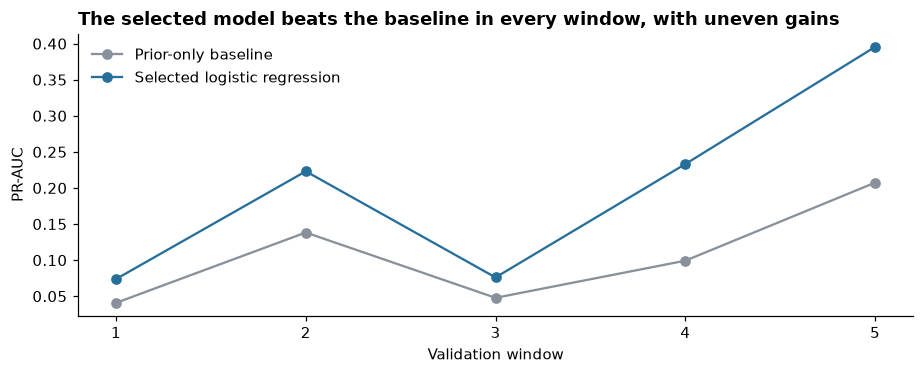

In [9]:
def ladder_row(step, line): return ladder.loc[ladder.step.eq(step) & ladder.line.eq(line)].iloc[0]
s2, s3, s4 = [ladder_row(s,"linear") for s in [2,3,4]]
s5, s6, s7, s8 = [ladder_row(s,"tree_based") for s in [5,6,7,8]]
l9, t9 = ladder_row(9,"linear"), ladder_row(9,"tree_based")
l10, t10 = ladder_row(10,"linear"), ladder_row(10,"tree_based")
l11, t11 = ladder_row(11,"linear"), ladder_row(11,"tree_based")
l12 = ladder_row(12,"linear")
display(Markdown(f"""**What we learned.** Default logistic regression adds **{s2.delta_average_precision:+.3f}** mean PR-AUC over the prior baseline; stronger regularisation adds **{s3.delta_average_precision:+.3f}**. Class weighting at the default strength *lowers* it by **{abs(s4.delta_average_precision):.3f}** and improves **{int(s4.folds_improved_ap)} of {len(folds)}** windows. A free-standing tree barely beats the baseline; constraining it adds **{s6.delta_average_precision:+.3f}**. A forest improves on that tree family, and constraining the forest adds **{s8.delta_average_precision:+.3f}** over its default.

Removing month improves logistic regression by **{l9.delta_average_precision:+.3f}** in **{int(l9.folds_improved_ap)} of {len(folds)}** windows and the forest by **{t9.delta_average_precision:+.3f}** in **{int(t9.folds_improved_ap)} of {len(folds)}**. Route history adds only **{l10.delta_average_precision:+.3f}** for logistic, versus **{t10.delta_average_precision:+.3f}** for forest. Seller history adds **{l11.delta_average_precision:+.3f}** and **{t11.delta_average_precision:+.3f}**, respectively; the forest gain is too small to call meaningful. Transforming skewed numbers adds **{l12.delta_average_precision:+.3f}** for logistic. These are validation-guided changes, so their scores are selection evidence."""))
final_cv = cv[cv.stage.eq("final_grid")]
subset = final_cv[final_cv.candidate.isin([selection["selected_candidate"], "prior_baseline"])]
fig, ax = plt.subplots(figsize=(8.5,3.5))
for candidate,color,label in [("prior_baseline",BASE,"Prior-only baseline"),
                              (selection["selected_candidate"],LINEAR,"Selected logistic regression")]:
    d = subset[subset.candidate.eq(candidate)].sort_values("fold")
    ax.plot(d.fold+1, d.average_precision, "o-", color=color, label=label)
ax.set_xticks(folds.fold+1); ax.set_xlabel("Validation window")
ax.set_ylabel("PR-AUC"); ax.legend(frameon=False)
ax.set_title("The selected model beats the baseline in every window, with uneven gains", loc="left")
plt.tight_layout(); plt.show()

In [10]:
payment_view = payments.copy()
payment_view["model"] = payment_view.algorithm.map({"linear":"Logistic", "tree":"Decision tree", "forest":"Random forest"})
display(payment_view[["model","with_payment_ap","without_payment_ap","delta_without_minus_with"]].rename(columns={
    "model":"Model", "with_payment_ap":"With payment", "without_payment_ap":"Without payment",
    "delta_without_minus_with":"Without − with"}).style.format(precision=4).hide(axis="index"))
display(Markdown(f"**What we learned.** Removing payment fields changes mean PR-AUC by at most **{payments.delta_without_minus_with.abs().max():.4f}** in these paired checks. This does not establish that payment data were recorded at the intended checkout moment; it shows the results are not very sensitive to them."))

Model,With payment,Without payment,Without − with
Logistic,0.2003,0.2001,-0.0002
Decision tree,0.1495,0.1499,0.0004
Random forest,0.1999,0.1995,-0.0005


**What we learned.** Removing payment fields changes mean PR-AUC by at most **0.0005** in these paired checks. This does not establish that payment data were recorded at the intended checkout moment; it shows the results are not very sensitive to them.

## 6. Why did the forest catch up?

**The question.** Why did a simple linear model lead early, while the final forest nearly matched it?

Trees can discover complicated combinations, but those can also reflect quirks of one period. The added route and seller summaries place useful comparisons directly in the inputs, so a forest has less to discover from sparse combinations. This is an interpretation of the validation pattern, not proof of a mechanism.

In [11]:
first_gap = s3.mean_average_precision - s8.mean_average_precision
last_gap = chosen - forest_ap
random_forest = splits.query('candidate == "forest_depth12" and split == "random"').iloc[0]
random_linear = splits.query('candidate == "logistic_c01" and split == "random"').iloc[0]
display(Markdown(f"""**What we learned.** On the original features, the leading logistic setting was ahead of the constrained forest by **{first_gap:.3f}** mean PR-AUC. On the final features, their gap is **{last_gap:.4f}**—effectively a tie, not evidence that the linear model is intrinsically better. In the shuffled comparison within the training period, the forest scores **{random_forest.mean_average_precision:.3f}** versus **{random_linear.mean_average_precision:.3f}** for logistic regression. A later voting comparison can check whether combining their different rankings helps."""))

**What we learned.** On the original features, the leading logistic setting was ahead of the constrained forest by **0.012** mean PR-AUC. On the final features, their gap is **0.0003**—effectively a tie, not evidence that the linear model is intrinsically better. In the shuffled comparison within the training period, the forest scores **0.327** versus **0.303** for logistic regression. A later voting comparison can check whether combining their different rankings helps.

## 7. What did the models use?

**The question.** Which inputs seem to influence the rankings, and how cautiously should we read them?

For logistic regression, an odds ratio above one means higher *modelled odds* of lateness when an input rises; below one means lower odds. The saved values come from separate fits in the validation windows, so the chart shows their median and range. Numeric odds ratios describe a one-standard-deviation change in the model input; some inputs were log-transformed first. These are associations, not causal effects.

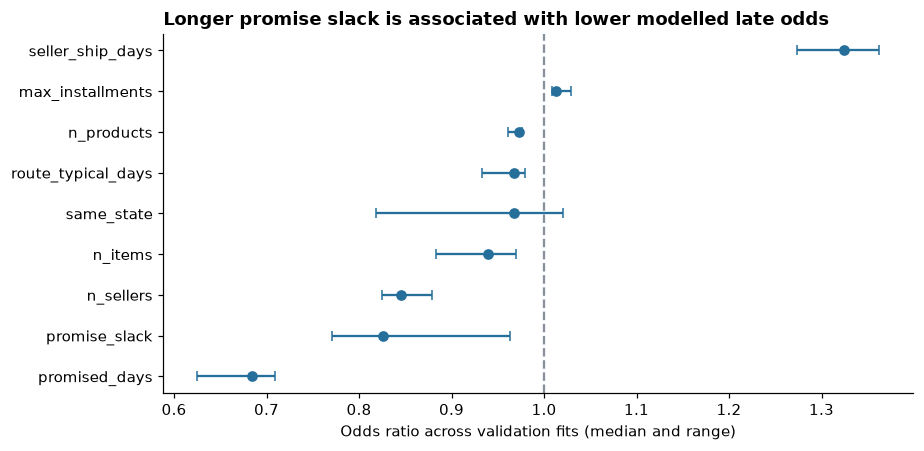

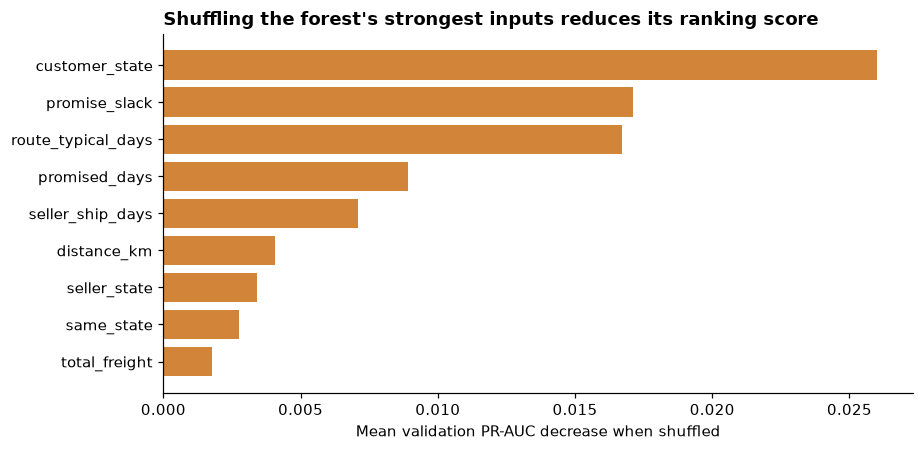

**What we learned.** The models use promise, route and seller information, but related inputs share predictive credit. One-hot state categories are omitted from the odds chart because their estimates are relative to a reference category and can be noisy for rare states. A feature's importance or coefficient does not prove it causes delays.

In [12]:
numeric = odds[odds.feature.str.startswith("numeric__")].copy()
numeric["feature"] = numeric.feature.str.removeprefix("numeric__")
ors = numeric.groupby("feature").odds_ratio.agg(["median","min","max"])
ors["strength"] = np.abs(np.log(ors["median"]))
ors = ors.sort_values("strength", ascending=False).head(9).sort_values("median")
fig, ax = plt.subplots(figsize=(8.5,4.2))
y = np.arange(len(ors))
ax.errorbar(ors["median"],y,xerr=[ors["median"]-ors["min"],ors["max"]-ors["median"]],fmt="o",color=LINEAR,capsize=3)
ax.axvline(1,color=BASE,ls="--");ax.set_yticks(y,ors.index)
ax.set_xlabel("Odds ratio across validation fits (median and range)")
ax.set_title("Longer promise slack is associated with lower modelled late odds",loc="left")
plt.tight_layout();plt.show()
imp = importance.groupby("feature").importance_mean.agg(["mean","min","max"])
imp["strength"] = imp["mean"].abs();imp = imp.sort_values("strength",ascending=False).head(9).sort_values("mean")
fig,ax=plt.subplots(figsize=(8.5,4.2))
y=np.arange(len(imp));ax.barh(y,imp["mean"],color=FOREST)
ax.set_yticks(y,imp.index);ax.axvline(0,color=BASE,lw=1)
ax.set_xlabel("Mean validation PR-AUC decrease when shuffled")
ax.set_title("Shuffling the forest's strongest inputs reduces its ranking score",loc="left")
plt.tight_layout();plt.show()
display(Markdown("**What we learned.** The models use promise, route and seller information, but related inputs share predictive credit. One-hot state categories are omitted from the odds chart because their estimates are relative to a reference category and can be noisy for rare states. A feature's importance or coefficient does not prove it causes delays."))

## 8. Use the ranking before choosing an alert cutoff

**The question.** If staff can review a fixed share of orders, how many late deliveries rise to the top?

A team can sort each new batch by risk and review the top share its capacity allows. The saved ranking selects the top share **within each validation window**, so it respects changing conditions rather than applying one global cutoff.

Share reviewed,Orders reviewed,Late orders found,Share of late orders found,Share of reviewed orders late,Lift vs random
10%,3805,951,23.5%,25.0%,2.34×
20%,7605,1614,39.8%,21.2%,1.99×
30%,11405,2098,51.8%,18.4%,1.72×


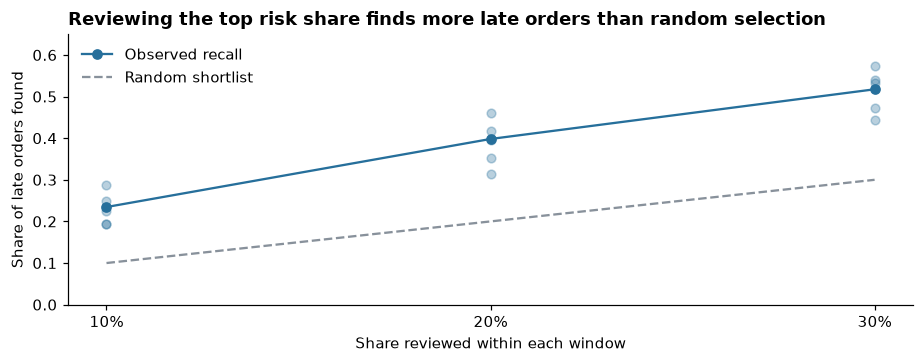

**What we learned.** Reviewing the top **10%** finds **951** of **4,054** late validation orders. That is **23.5%** recall and **2.34×** random selection, pooled across the separately ranked windows. It suggests prioritisation, not a calibrated probability or a guaranteed operational benefit.

In [13]:
overall = ranking[ranking.scope.eq("all_folds")].sort_values("top_share")
view = overall[["top_share","flagged","caught","recall","precision","lift"]].rename(columns={
    "top_share":"Share reviewed", "flagged":"Orders reviewed", "caught":"Late orders found",
    "recall":"Share of late orders found", "precision":"Share of reviewed orders late", "lift":"Lift vs random"})
display(view.style.format({"Share reviewed":"{:.0%}","Share of late orders found":"{:.1%}",
                           "Share of reviewed orders late":"{:.1%}","Lift vs random":"{:.2f}×"}).hide(axis="index"))
fig,ax=plt.subplots(figsize=(8.5,3.4))
ax.plot(overall.top_share,overall.recall,"o-",color=LINEAR,label="Observed recall")
ax.plot(overall.top_share,overall.top_share,"--",color=BASE,label="Random shortlist")
for f in sorted(predictions.fold.unique()):
    d=ranking[ranking.scope.eq(f"fold_{f}")].sort_values("top_share")
    ax.scatter(d.top_share,d.recall,color=LINEAR,alpha=.32,s=32)
ax.set_xticks(overall.top_share,[f"{x:.0%}" for x in overall.top_share]);ax.set_ylim(0,.65)
ax.set_xlabel("Share reviewed within each window");ax.set_ylabel("Share of late orders found")
ax.legend(frameon=False)
ax.set_title("Reviewing the top risk share finds more late orders than random selection",loc="left")
plt.tight_layout();plt.show()
display(Markdown(f"**What we learned.** Reviewing the top **{top10.top_share:.0%}** finds **{top10.caught:,}** of **{top10.late:,}** late validation orders. That is **{top10.recall:.1%}** recall and **{top10.lift:.2f}×** random selection, pooled across the separately ranked windows. It suggests prioritisation, not a calibrated probability or a guaranteed operational benefit."))

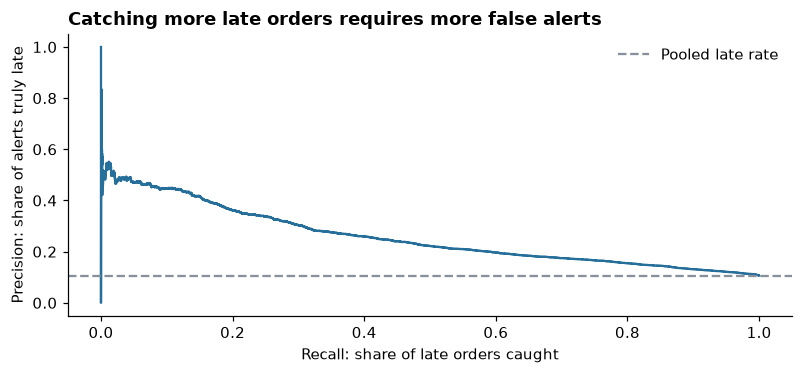

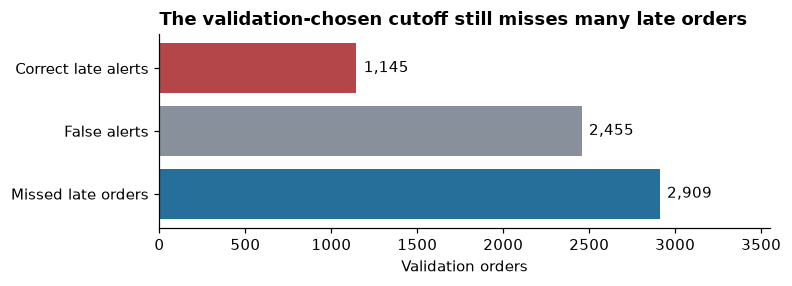

**What we learned.** The provisional MCC cutoff flags **3,600** pooled validation orders: **1,145** correct late alerts, **2,455** false alerts, and **2,909** missed late orders. Its pooled precision is **31.8%**, recall **28.2%**, and MCC **0.222**. This cutoff was *chosen and measured on the same validation predictions*, so those numbers are optimistic selection evidence. The curve and these values pool windows with different late rates; the main model-selection PR-AUC above is a mean of per-window scores.

In [14]:
precision, recall, _ = precision_recall_curve(predictions.is_late, predictions.probability)
pooled_rate=predictions.is_late.mean()
fig,ax=plt.subplots(figsize=(7.4,3.5))
ax.plot(recall,precision,color=LINEAR)
ax.axhline(pooled_rate,color=BASE,ls="--",label="Pooled late rate")
ax.set_xlabel("Recall: share of late orders caught")
ax.set_ylabel("Precision: share of alerts truly late")
ax.legend(frameon=False)
ax.set_title("Catching more late orders requires more false alerts",loc="left")
plt.tight_layout();plt.show()
chosen_threshold=thresholds[thresholds.rule.eq("validation_selected_mcc")].iloc[0]
fig,ax=plt.subplots(figsize=(7.3,2.7))
counts=[chosen_threshold.true_positive,chosen_threshold.false_positive,chosen_threshold.false_negative]
names=["Correct late alerts","False alerts","Missed late orders"]
ax.barh(names[::-1],counts[::-1],color=[LATE,BASE,LINEAR][::-1])
for y,n in enumerate(counts[::-1]):ax.text(n+max(counts)*.015,y,f"{int(n):,}",va="center")
ax.set_xlim(0,max(counts)*1.22);ax.set_xlabel("Validation orders")
ax.set_title("The validation-chosen cutoff still misses many late orders",loc="left")
plt.tight_layout();plt.show()
alerts=int(chosen_threshold.true_positive+chosen_threshold.false_positive)
display(Markdown(f"**What we learned.** The provisional MCC cutoff flags **{alerts:,}** pooled validation orders: **{int(chosen_threshold.true_positive):,}** correct late alerts, **{int(chosen_threshold.false_positive):,}** false alerts, and **{int(chosen_threshold.false_negative):,}** missed late orders. Its pooled precision is **{chosen_threshold.precision:.1%}**, recall **{chosen_threshold.recall:.1%}**, and MCC **{chosen_threshold.mcc:.3f}**. This cutoff was *chosen and measured on the same validation predictions*, so those numbers are optimistic selection evidence. The curve and these values pool windows with different late rates; the main model-selection PR-AUC above is a mean of per-window scores."))

## 9. How much should we compare with other Olist projects?

**The question.** Do other projects make these results look plausible?

Other practitioner projects use the same public dataset but make different choices about prediction time, target, features and testing. For example, [ArmutS](https://github.com/ArmutS/olist-delivery-risk) predicts at approval rather than checkout; [Haneen Dahbour](https://github.com/HaneenDahbour/olist-late-delivery-mlops) describes a later-period performance drop; and [junxuanc](https://github.com/junxuanc/olist-delay-prediction-analysis) uses a random split. These are self-published projects, not matched benchmarks or peer-reviewed estimates.

**What we learned.** External scores can flag implausible claims, but they cannot rank our model against a differently defined experiment. Our own same-window comparisons carry the decision.

## 10. Limits and next work

**The question.** What remains uncertain before this can guide a real intervention?

- The labels cover eventually delivered orders only. This model cannot estimate cancellation or non-delivery risk for every new purchase.
- Checkout availability of some product, payment, seller and promise fields is assumed because the source tables do not contain full change histories.
- The late rate shifts sharply over time; the later-period test also excludes the earlier peak-shopping season.
- A small number of orders near the end of the historical data may not have complete outcomes. The validation design reduces, but cannot eliminate, this issue.
- Feature ideas and the alert cutoff were assessed using the same validation windows. The reported results are for model choice, not an unbiased final score.
- An alert's value depends on staffing capacity and the cost of false versus missed alerts, which have not been specified.

**What we learned.** Next come delivery-time regression, a voting comparison of the linear and forest rankings, and one reserved later-period evaluation after choices are fixed.

## 11. Reproduce this review

**The question.** Where did the displayed evidence come from?

The saved figures and tables come from `results/phase2/classification/`. The training code is `phase2_classification.py`; the feature history code is `phase2_features.py`; the raw preparation is in `data_prep.ipynb`. This notebook checks that the saved inputs and implementation match its metadata, then displays results. It does not rerun fitting. Run from the repository root or this notebook directory with the project environment.

In [15]:
display(Markdown(f"**What we learned.** The saved run used seed **{selection['random_state']}**, Python **{selection['environment']['python']}**, scikit-learn **{selection['environment']['sklearn']}**, and **{len(folds)}** future-facing validation windows. The saved metadata confirms no final model fit or reserved test evaluation. To reproduce the modelling separately, run `it5006-proj/bin/python phase2_classification.py` from the repository root; this notebook only reads its outputs."))

**What we learned.** The saved run used seed **42**, Python **3.14.7**, scikit-learn **1.9.1**, and **5** future-facing validation windows. The saved metadata confirms no final model fit or reserved test evaluation. To reproduce the modelling separately, run `it5006-proj/bin/python phase2_classification.py` from the repository root; this notebook only reads its outputs.